Task 2: Quantitative analysis using pynance and TaLib

Prepare my Data

In [11]:
import pandas as pd

df = pd.read_csv("../data/META.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


In [12]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.info()
df.isnull().sum()
df = df.dropna()

<class 'pandas.DataFrame'>
DatetimeIndex: 2923 entries, 2012-05-18 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2923 non-null   float64
 1   High    2923 non-null   float64
 2   Low     2923 non-null   float64
 3   Open    2923 non-null   float64
 4   Volume  2923 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 137.0 KB


Compute SMA

In [13]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()

df['SMA_50'] = df['Close'].rolling(window=50).mean()

Compute EMA

In [14]:
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

Compute RSI

In [15]:
import ta

df['RSI'] = ta.momentum.RSIIndicator(df['Close']).rsi()

Compute MACD

In [16]:
macd = ta.trend.MACD(df['Close'])

df['MACD'] = macd.macd()

df['MACD_signal'] = macd.macd_signal()

Price + Moving Average Plot

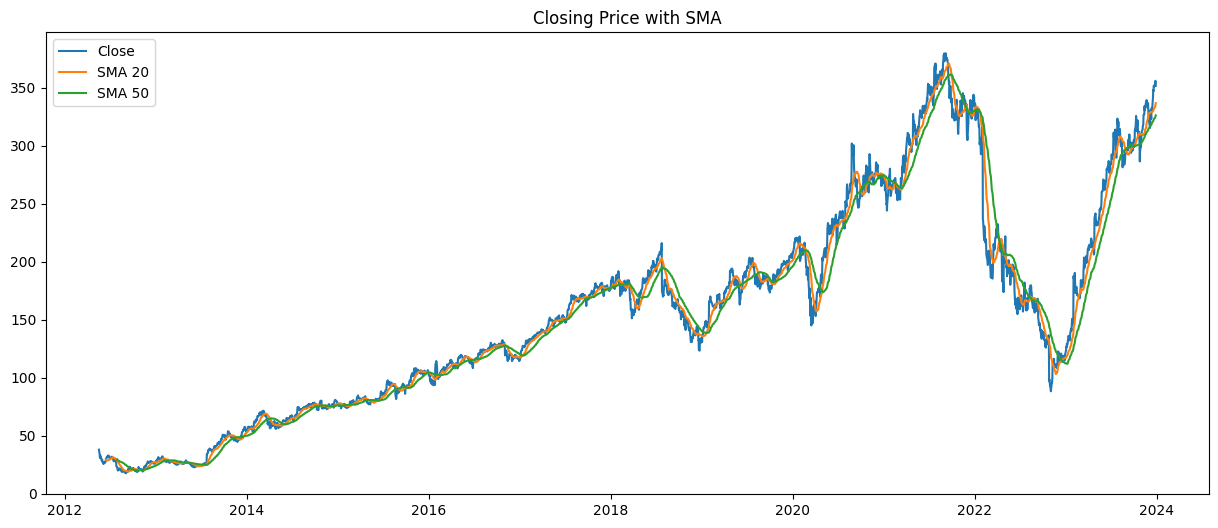

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close')

plt.plot(df['SMA_20'], label='SMA 20')

plt.plot(df['SMA_50'], label='SMA 50')

plt.legend()

plt.title("Closing Price with SMA")

plt.show()

RSI Plot

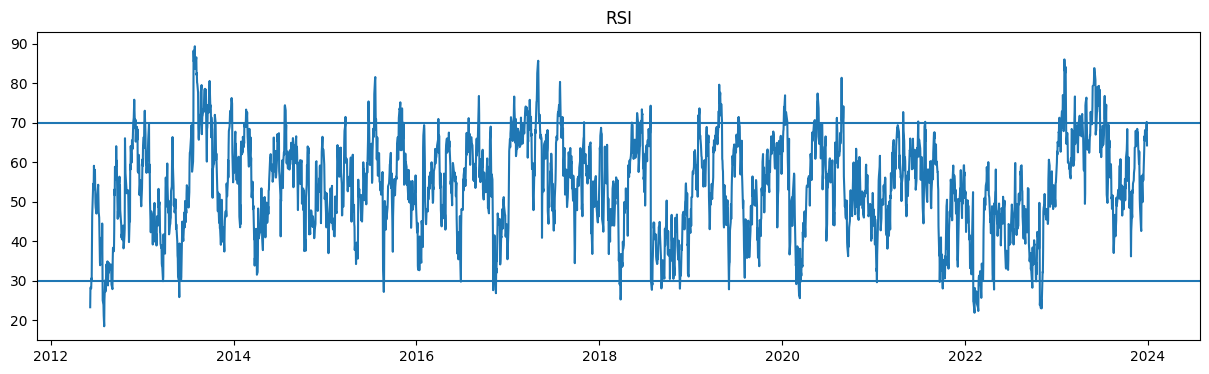

In [18]:
plt.figure(figsize=(15,4))

plt.plot(df['RSI'])

plt.axhline(70)

plt.axhline(30)

plt.title("RSI")

plt.show()

RSI > 70 → stoke overbought
RSI < 30 → stoke oversold

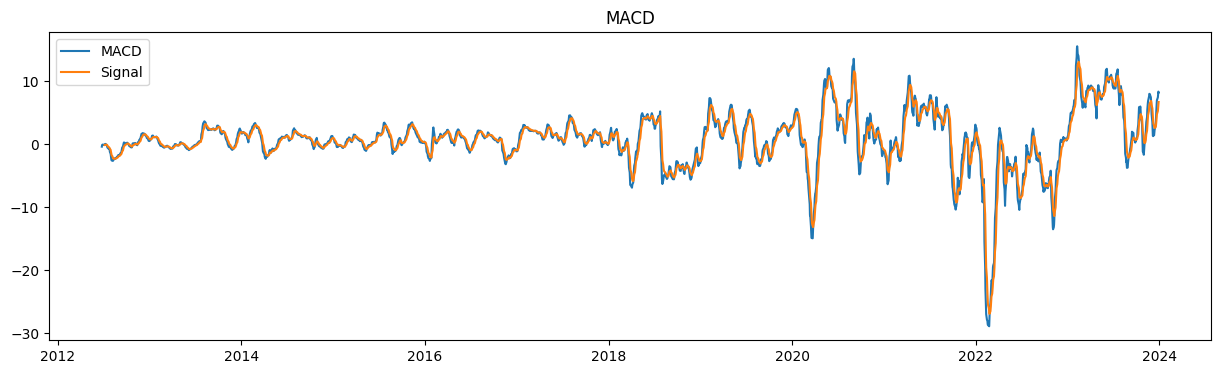

In [19]:
plt.figure(figsize=(15,4))

plt.plot(df['MACD'], label='MACD')

plt.plot(df['MACD_signal'], label='Signal')

plt.legend()

plt.title("MACD")

plt.show()

In [20]:

df['daily_return'] = df['Close'].pct_change()
df['daily_return'].describe()

count    2922.000000
mean        0.001082
std         0.025280
min        -0.263901
25%        -0.010045
50%         0.000998
75%         0.012825
max         0.296115
Name: daily_return, dtype: float64